# FDA-style conditional flow on Allen Ca embeddings

**Paper-aligned setup** (Wang et al., ICML 2025 — [OpenReview](https://openreview.net/pdf?id=nKJEAQ6JCY),
[code](https://github.com/wangpuli/FDA)): at training time we learn a **continuous transport**
from a **standard Gaussian latent** \(x_0 \sim \mathcal{N}(0,I)\) to a **target neural embedding**
\(x_1\) (standardized **VISrl** or **VISp**), while the velocity field is **conditioned on the
observed neural window** \(c\) for that trial (e.g. **VISp** activity when \(x_1\) is **VISrl**).

Same SiT/FDA **probability path** as `flow/transport/path.py`:
\(x_t = \alpha(t) x_1 + \sigma(t) x_0\),
\(u_t = \alpha'(t) x_1 + \sigma'(t) x_0\), with **IC** (linear) or **GVP** plan. The network predicts
**\(v_\theta(x_t, t, c)\)** and is trained with flow matching to match \(u_t\).

| File | Role |
|------|------|
| `signal_model.py` | `ConditionalVelocityFieldMLP`, `fda_conditional_flow_matching_loss`, `integrate_rk4_conditional`, plans, `aligned_minibatch`, `standard_gaussian_latent` |
| `fda_evaluation.py` | Paper-style **R² (%)** + **few-trial calibration** (cf. `tgt_train_ratio` / `ft_func.py` in the FDA repo) |
| `signal_decode.py` | `allen_frame_id_decode` (`modality='ca'`) |
| Data | `../data/allen_data/` (`VISp_*`, `VISrl_*` Ca train/test; see cell below) |

**Inference:** sample \(z \sim \mathcal{N}(0,I)\), set \(c\) to the test observation, integrate from \(t=0\) to \(1\), then decode (**kNN** and/or **linear R²** as in §6–6b).

## 1. Setup

In [25]:
import importlib.util
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def _find_signal_flow_dir() -> Path:
    """Works from signal_flow/, Flow_Hackathon/, or repo root (e.g. flow/)."""
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        for rel in (
            Path("signal_model.py"),
            Path("signal_flow") / "signal_model.py",
            Path("Flow_Hackathon") / "signal_flow" / "signal_model.py",
        ):
            p = d / rel
            if p.is_file():
                return p.parent
    raise FileNotFoundError(
        "Could not find signal_model.py. cd to Flow_Hackathon/signal_flow or open the notebook from that folder."
    )


def _load_module(name: str, path: Path):
    """Load from disk so edits + re-run work (avoids stale `signal_model` in sys.modules)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


FLOW_DIR = _find_signal_flow_dir()
if str(FLOW_DIR) not in sys.path:
    sys.path.insert(0, str(FLOW_DIR))

_sm = _load_module("signal_model", FLOW_DIR / "signal_model.py")
_sd = _load_module("signal_decode", FLOW_DIR / "signal_decode.py")

GVPCPlan = _sm.GVPCPlan
ICPlan = _sm.ICPlan
ConditionalVelocityFieldMLP = _sm.ConditionalVelocityFieldMLP
fda_conditional_flow_matching_loss = _sm.fda_conditional_flow_matching_loss
integrate_rk4_conditional = _sm.integrate_rk4_conditional
aligned_minibatch = _sm.aligned_minibatch
standard_gaussian_latent = _sm.standard_gaussian_latent
allen_frame_id_decode = _sd.allen_frame_id_decode

_fe = _load_module("fda_evaluation", FLOW_DIR / "fda_evaluation.py")
fda_metrics_sweep = _fe.fda_metrics_sweep
print_fda_sweep_table = _fe.print_fda_sweep_table

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("signal_flow:", FLOW_DIR)

device: cuda
signal_flow: /home/fachengy/flow/Flow_Hackathon/signal_flow


## 2. Load Ca embeddings (train / test)

Paths follow `Demo_Allen.ipynb` save pattern under `Flow_Hackathon/data/allen_data/`.

In [26]:
DATA_DIR = (FLOW_DIR.parent / "data" / "allen_data").resolve()
seed = 333

paths = {
    "visp_train": DATA_DIR / f"VISp_joint_trained_ca_{seed}_train.npy",
    "visp_test": DATA_DIR / f"VISp_joint_trained_ca_{seed}_test.npy",
    "visrl_train": DATA_DIR / f"VISrl_joint_trained_ca_{seed}_train.npy",
    "visrl_test": DATA_DIR / f"VISrl_joint_trained_ca_{seed}_test.npy",
}
for k, p in paths.items():
    assert p.is_file(), f"Missing {k}: {p}"

visp_train = np.load(paths["visp_train"]).astype(np.float32)
visp_test = np.load(paths["visp_test"]).astype(np.float32)
visrl_train = np.load(paths["visrl_train"]).astype(np.float32)
visrl_test = np.load(paths["visrl_test"]).astype(np.float32)

for name, a in [
    ("VISp train", visp_train),
    ("VISp test", visp_test),
    ("VISrl train", visrl_train),
    ("VISrl test", visrl_test),
]:
    print(f"{name}: shape {a.shape}")

VISp train: shape (8100, 128)
VISp test: shape (900, 128)
VISrl train: shape (8100, 128)
VISrl test: shape (900, 128)


## 3. Z-normalize per area (fit on train)

Torch tensors below are used to build **aligned** \((x_1, c)\) pairs and test-time **\(c\)**. The generative path always ends in the **target** area’s z-space (set `FLOW_MODE` in the next section).

In [27]:
eps = 1e-6


def standardize(x, mu, std):
    return (x - mu) / std


mu_visp, std_visp = visp_train.mean(0), visp_train.std(0) + eps
mu_visrl, std_visrl = visrl_train.mean(0), visrl_train.std(0) + eps

z_visp_tr = standardize(visp_train, mu_visp, std_visp)
z_visp_te = standardize(visp_test, mu_visp, std_visp)
z_visrl_tr = standardize(visrl_train, mu_visrl, std_visrl)
z_visrl_te = standardize(visrl_test, mu_visrl, std_visrl)

z_visp_tr_t = torch.from_numpy(z_visp_tr).to(device)
z_visp_te_t = torch.from_numpy(z_visp_te).to(device)
z_visrl_tr_t = torch.from_numpy(z_visrl_tr).to(device)
z_visrl_te_t = torch.from_numpy(z_visrl_te).to(device)
dim = z_visp_tr.shape[1]
print("dim:", dim, "| train:", z_visp_tr_t.shape, z_visrl_tr_t.shape)

dim: 128 | train: torch.Size([8100, 128]) torch.Size([8100, 128])


## 4. Train conditional velocity field (FDA flow matching)

Sample \(x_0 \sim \mathcal{N}(0,I)\), trial-aligned \(x_1\) and condition \(c\) (see `FLOW_MODE`), build \((x_t,u_t)\) from the plan, minimize \(\mathbb{E}\|v_\theta(x_t,t,c) - u_t\|^2\).

- **`cross_visrl`:** \(x_1=\) VISrl, \(c=\) VISp (same trial) — adaptation-style conditioning.  
- **`visrl_denoise` / `visp_denoise`:** \(c = x_1 + \sigma\varepsilon\) so the flow is learned in one area.

step     0  loss 2.009331
step   500  loss 1.070655
step  1000  loss 1.060393
step  1500  loss 1.062376
step  2000  loss 1.037392
step  2500  loss 0.996672
step  2999  loss 0.957244


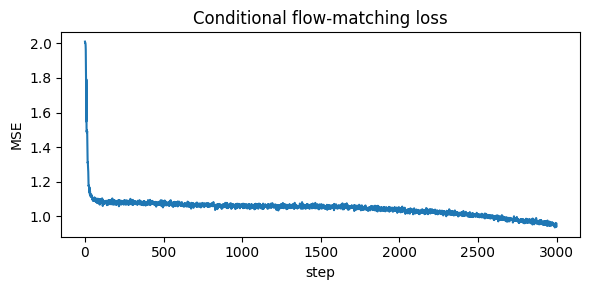

In [28]:
# cross_visrl: x1=VISrl, c=VISp (aligned trials). Denoise modes: c = x1 + noise (same area).
FLOW_MODE = "cross_visrl"
COND_NOISE_STD = 0.25  # used only for visrl_denoise / visp_denoise

model = ConditionalVelocityFieldMLP(
    data_dim=dim,
    hidden_dim=512,
    time_emb_dim=128,
    ctx_dim=128,
    n_layers=5,
    dropout=0.05,
).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

BATCH = 512
STEPS = 3000
TRAIN_EPS = 1e-5
PATH_TYPE = "linear"
plan = ICPlan() if PATH_TYPE == "linear" else GVPCPlan()

train_gen = torch.Generator(device=device)
train_gen.manual_seed(0)

losses = []
model.train()
for step in range(STEPS):
    if FLOW_MODE == "cross_visrl":
        x1_b, cond_b = aligned_minibatch(
            z_visrl_tr_t, z_visp_tr_t, batch_size=BATCH, generator=train_gen
        )
    elif FLOW_MODE == "visrl_denoise":
        (x1_b,) = aligned_minibatch(
            z_visrl_tr_t, batch_size=BATCH, generator=train_gen
        )
        cond_b = x1_b + COND_NOISE_STD * torch.randn(
            x1_b.shape, device=device, dtype=x1_b.dtype, generator=train_gen
        )
    elif FLOW_MODE == "visp_denoise":
        (x1_b,) = aligned_minibatch(
            z_visp_tr_t, batch_size=BATCH, generator=train_gen
        )
        cond_b = x1_b + COND_NOISE_STD * torch.randn(
            x1_b.shape, device=device, dtype=x1_b.dtype, generator=train_gen
        )
    else:
        raise ValueError(FLOW_MODE)

    x0_b = standard_gaussian_latent(
        BATCH, dim, device=device, dtype=x1_b.dtype, generator=train_gen
    )
    loss = fda_conditional_flow_matching_loss(
        model, x0_b, x1_b, cond_b, plan, train_eps=TRAIN_EPS
    )
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 500 == 0 or step == STEPS - 1:
        print(f"step {step:5d}  loss {loss.item():.6f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("MSE")
plt.title("Conditional flow-matching loss")
plt.tight_layout()
plt.show()

## 5. Sample \(z \sim \mathcal{N}(0,I)\), integrate to \(t=1\)

Integrate \(dX/dt = v_\theta(X,t,c)\) with test-time **\(c\)** from the observed window. For denoise modes you can add optional noise to **\(c\)** at test time and compare kNN on **\(c\)** vs on the flow output.

In [29]:
# Optional test-time corruption of c for denoise experiments (0 = clean observation)
TEST_COND_NOISE_STD = 0.0

infer_gen = torch.Generator(device=device)
infer_gen.manual_seed(42)

if FLOW_MODE == "cross_visrl":
    cond_te = z_visp_te_t
    target_tr_np, target_te_np = z_visrl_tr, z_visrl_te
elif FLOW_MODE == "visrl_denoise":
    cond_te = z_visrl_te_t.clone()
    target_tr_np, target_te_np = z_visrl_tr, z_visrl_te
elif FLOW_MODE == "visp_denoise":
    cond_te = z_visp_te_t.clone()
    target_tr_np, target_te_np = z_visp_tr, z_visp_te
else:
    raise ValueError(FLOW_MODE)

if FLOW_MODE.endswith("denoise") and TEST_COND_NOISE_STD > 0:
    cond_te = cond_te + TEST_COND_NOISE_STD * torch.randn(
        cond_te.shape, device=device, dtype=cond_te.dtype, generator=infer_gen
    )

n_te = cond_te.shape[0]
with torch.no_grad():
    z0 = standard_gaussian_latent(
        n_te, dim, device=device, dtype=cond_te.dtype, generator=infer_gen
    )
    x_hat = integrate_rk4_conditional(
        model, z0, cond_te, n_steps=100, t_start=0.0, t_end=1.0
    )
z_flow_test = x_hat.cpu().numpy()
cond_te_np = cond_te.cpu().numpy()
print("Flow output shape:", z_flow_test.shape)

Flow output shape: (900, 128)


## 6. Frame-ID decoding (`modality='ca'`)

kNN on **target-area** train embeddings vs test features (full train bank).

- **Oracle:** target train → target test (upper reference).  
- **Domain shift** (`cross_visrl` only): VISrl train → VISp test (z-standardized separately).  
- **Cond-only** (`*_denoise` with `TEST_COND_NOISE_STD > 0`): kNN on noisy **\(c\)**.  
- **Flow:** same bank → **\(z\)**-integrated representation.

### 6b. FDA paper-style metrics (next cell)

**R² (%)** as in the official FDA repo (`sklearn.metrics.r2_score` × 100 on 2D behavior). Here behavior is **sin/cos(frame)** (same dimensionality as 2D velocity in the paper). **Few-trial calibration** subsamples the target train bank by `calibration_ratio` (default includes **0.02**, matching `tgt_train_ratio` in `test_FDA_on_spikes_ft.py`), averaged over seeds.

In [30]:
train_labels = np.tile(np.arange(900), 9)
test_labels = np.arange(900)
assert len(train_labels) == target_tr_np.shape[0]
assert len(test_labels) == target_te_np.shape[0]

_, _, acc_oracle = allen_frame_id_decode(
    target_tr_np,
    train_labels,
    target_te_np,
    test_labels,
    modality="ca",
    decoder="knn",
)

if FLOW_MODE == "cross_visrl":
    _, _, acc_shift = allen_frame_id_decode(
        target_tr_np,
        train_labels,
        z_visp_te,
        test_labels,
        modality="ca",
        decoder="knn",
    )
else:
    acc_shift = float("nan")

if FLOW_MODE.endswith("denoise") and TEST_COND_NOISE_STD > 0:
    _, _, acc_cond = allen_frame_id_decode(
        target_tr_np,
        train_labels,
        cond_te_np,
        test_labels,
        modality="ca",
        decoder="knn",
    )
else:
    acc_cond = float("nan")

_, _, acc_flow = allen_frame_id_decode(
    target_tr_np,
    train_labels,
    z_flow_test,
    test_labels,
    modality="ca",
    decoder="knn",
)

print(f"Oracle ({FLOW_MODE})     train→test target:  {acc_oracle:.2f}%")
if FLOW_MODE == "cross_visrl":
    print(f"Shift   VISrl train → VISp test:          {acc_shift:.2f}%")
if not np.isnan(acc_cond):
    print(f"Cond-only (noisy c):                    {acc_cond:.2f}%")
print(f"Flow    z+N(0,I) + integrate + decode:    {acc_flow:.2f}%")

Oracle (cross_visrl)     train→test target:  11.67%
Shift   VISrl train → VISp test:          3.44%
Flow    z+N(0,I) + integrate + decode:    32.89%


In [31]:
# FDA repo style: R² (%) + same few-trial subsampling for kNN (cf. tgt_train_ratio = 0.02)
FDA_CALIBRATION_RATIOS = (0.02, 0.05, 0.1, 1.0)
FDA_CALIBRATION_SEEDS = (0, 1, 2)

test_cases_fda = [
    ("oracle", target_te_np),
    ("flow", z_flow_test),
]
method_order = ["oracle", "flow"]

if FLOW_MODE == "cross_visrl":
    test_cases_fda.append(("shift_visp", z_visp_te))
    method_order.append("shift_visp")

if FLOW_MODE.endswith("denoise") and TEST_COND_NOISE_STD > 0:
    test_cases_fda.append(("cond", cond_te_np))
    method_order.append("cond")

rows_fda = fda_metrics_sweep(
    target_tr_np,
    train_labels,
    test_cases_fda,
    test_labels,
    calibration_ratios=FDA_CALIBRATION_RATIOS,
    calibration_seeds=FDA_CALIBRATION_SEEDS,
    ridge_alpha=1.0,
    modality="ca",
)
print_fda_sweep_table(rows_fda, method_order)

/home/fachengy/miniconda3/envs/hiatus/lib/python3.12/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
/home/fachengy/miniconda3/envs/hiatus/lib/python3.12/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
/home/fachengy/miniconda3/envs/hiatus/lib/python3.12/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
/home/fachengy/miniconda3/envs/hiatus/lib/python3.12/site-packages/sklearn/utils/mult


=== FDA-style evaluation (R² % + kNN acc %, few-trial calibration) ===
R²: Ridge linear readout → sin/cos(frame) (2D behavior, cf. 2D velocity in the paper).
Few-trial: subsample target-area train bank (cf. tgt_train_ratio in FDA ft script).


-- calibration_ratio=0.02  (~162 train trials) --
  oracle            R² % = -53.51 ± 1.72   |   kNN acc % =  12.81
  flow              R² % = -107.63 ± 13.65   |   kNN acc % =  31.00
  shift_visp        R² % = -310.27 ± 131.87   |   kNN acc % =   1.44

-- calibration_ratio=0.05  (~405 train trials) --
  oracle            R² % = -58.39 ± 1.16   |   kNN acc % =  11.04
  flow              R² % = -171.48 ± 8.57   |   kNN acc % =  30.85
  shift_visp        R² % = -284.42 ± 89.52   |   kNN acc % =   2.78

-- calibration_ratio=0.1  (~810 train trials) --
  oracle            R² % = -59.68 ± 3.76   |   kNN acc % =  11.74
  flow              R² % = -202.58 ± 7.89   |   kNN acc % =  31.56
  shift_visp        R² % = -413.95 ± 164.29   |   kNN acc % =   2.3

## 7. Optional: 2D PCA glimpse

For `cross_visrl`: compare **VISrl test**, **VISp test** (domain shift), and **flow outputs** in a shared linear view.

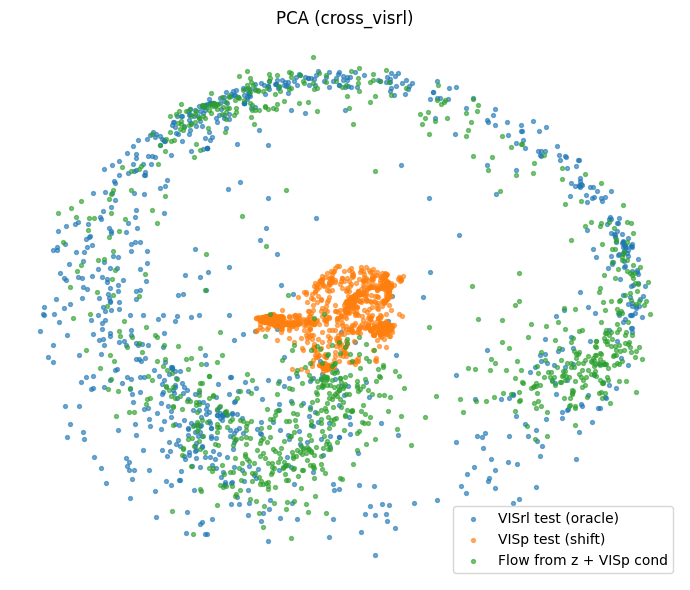

In [32]:
from sklearn.decomposition import PCA

if FLOW_MODE == "cross_visrl":
    Z = np.vstack([z_visrl_tr[::80], z_visrl_te, z_visp_te, z_flow_test])
    pca = PCA(n_components=2, random_state=0).fit(Z)

    def proj(A):
        return pca.transform(A)

    plt.figure(figsize=(7, 6))
    plt.scatter(*proj(z_visrl_te).T, s=8, alpha=0.6, label="VISrl test (oracle)")
    plt.scatter(*proj(z_visp_te).T, s=8, alpha=0.6, label="VISp test (shift)")
    plt.scatter(*proj(z_flow_test).T, s=8, alpha=0.6, label="Flow from z + VISp cond")
    plt.legend()
    plt.title("PCA (cross_visrl)")
elif FLOW_MODE.endswith("denoise"):
    Z = np.vstack([target_tr_np[::80], target_te_np, z_flow_test])
    pca = PCA(n_components=2, random_state=0).fit(Z)

    def proj(A):
        return pca.transform(A)

    plt.figure(figsize=(7, 6))
    plt.scatter(*proj(target_te_np).T, s=8, alpha=0.6, label="Target test (oracle)")
    plt.scatter(*proj(z_flow_test).T, s=8, alpha=0.6, label="Flow output")
    if TEST_COND_NOISE_STD > 0:
        plt.scatter(*proj(cond_te_np).T, s=8, alpha=0.6, label="Noisy cond c")
    plt.legend()
    plt.title(f"PCA ({FLOW_MODE})")
else:
    raise ValueError(FLOW_MODE)

plt.axis("off")
plt.tight_layout()
plt.show()